In [16]:
import sys
print(sys.version)

3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:57:12) [MSC v.1935 64 bit (AMD64)]


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
# from pmdarima.arima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pandas_datareader import DataReader
import datetime  
import math
from sklearn.metrics import r2_score
import yfinance as yf
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
# from pmdarima import auto_arima

In [25]:
data = pd.read_csv("inflow_data.csv")

In [26]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

In [27]:
# Convert 'Mn-Yr' to datetime format and set it as the index
data['Mn-Yr'] = pd.to_datetime(data['Mn-Yr'], format='%b-%y')
data.set_index('Mn-Yr', inplace=True)


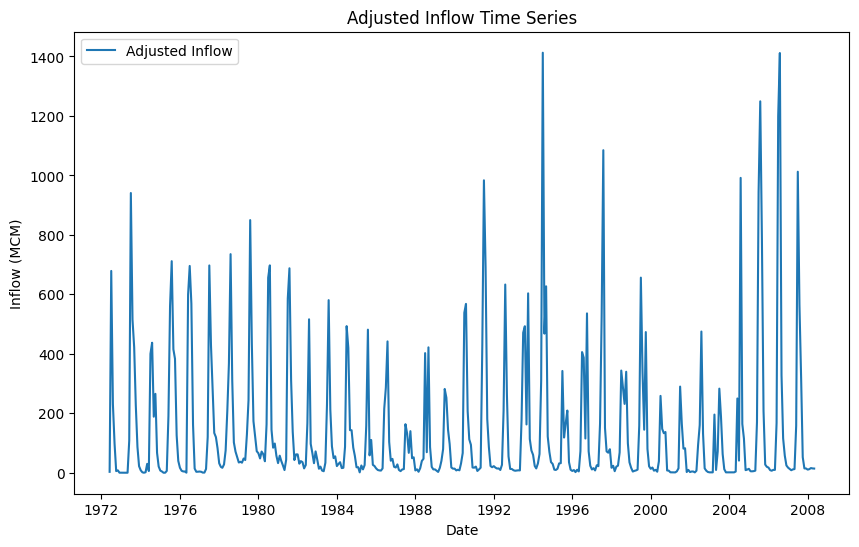

In [28]:
# Visualize the time series data
plt.figure(figsize=(10, 6))
plt.plot(data['Adj_Inflo'], label='Adjusted Inflow')
plt.title('Adjusted Inflow Time Series')
plt.xlabel('Date')
plt.ylabel('Inflow (MCM)')
plt.legend()
plt.show()

In [31]:
data.head()

,Inflo (MCM),Adj_Inflo
Mn-Yr,,
1972-06-01,3.030,3.030
1972-07-01,678.635,678.635
1972-08-01,230.355,230.355
1972-09-01,97.211,97.211
1972-10-01,5.493,5.493


In [32]:
data.tail

<bound method NDFrame.tail of             Inflo (MCM)  Adj_Inflo
Mn-Yr                             
1972-06-01        3.030      3.030
1972-07-01      678.635    678.635
1972-08-01      230.355    230.355
1972-09-01       97.211     97.211
1972-10-01        5.493      5.493
...                 ...        ...
2008-01-01       10.430     10.430
2008-02-01       12.040     12.040
2008-03-01       15.620     15.630
2008-04-01       14.460     14.460
2008-05-01       14.000     14.010

[432 rows x 2 columns]>

In [33]:
data.describe()

,Inflo (MCM),Adj_Inflo
count,432.000000,432.000000
mean,142.092787,142.430727
std,231.999767,231.900661
min,0.000000,0.000000
25%,10.817250,10.824250
50%,37.670500,38.665500
75%,161.361000,161.361000
max,1412.594000,1412.594000


In [34]:
data.columns

Index(['Inflo (MCM)', 'Adj_Inflo'], dtype='object')

## Step 2: Visualize the Data

In [35]:
# Perform the Dickey-Fuller test to check for stationarity
result = adfuller(data['Adj_Inflo'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'{key}: {value}')


ADF Statistic: -3.52492656041859
p-value: 0.007369534305719919
Critical Values:
1%: -3.4460914174990296
5%: -2.868479374038333
10%: -2.570466459559076


In [36]:
# Decompose the time series to analyze the trend and seasonality components
decomposition = seasonal_decompose(data['Adj_Inflo'], model='additive', period=12)
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid


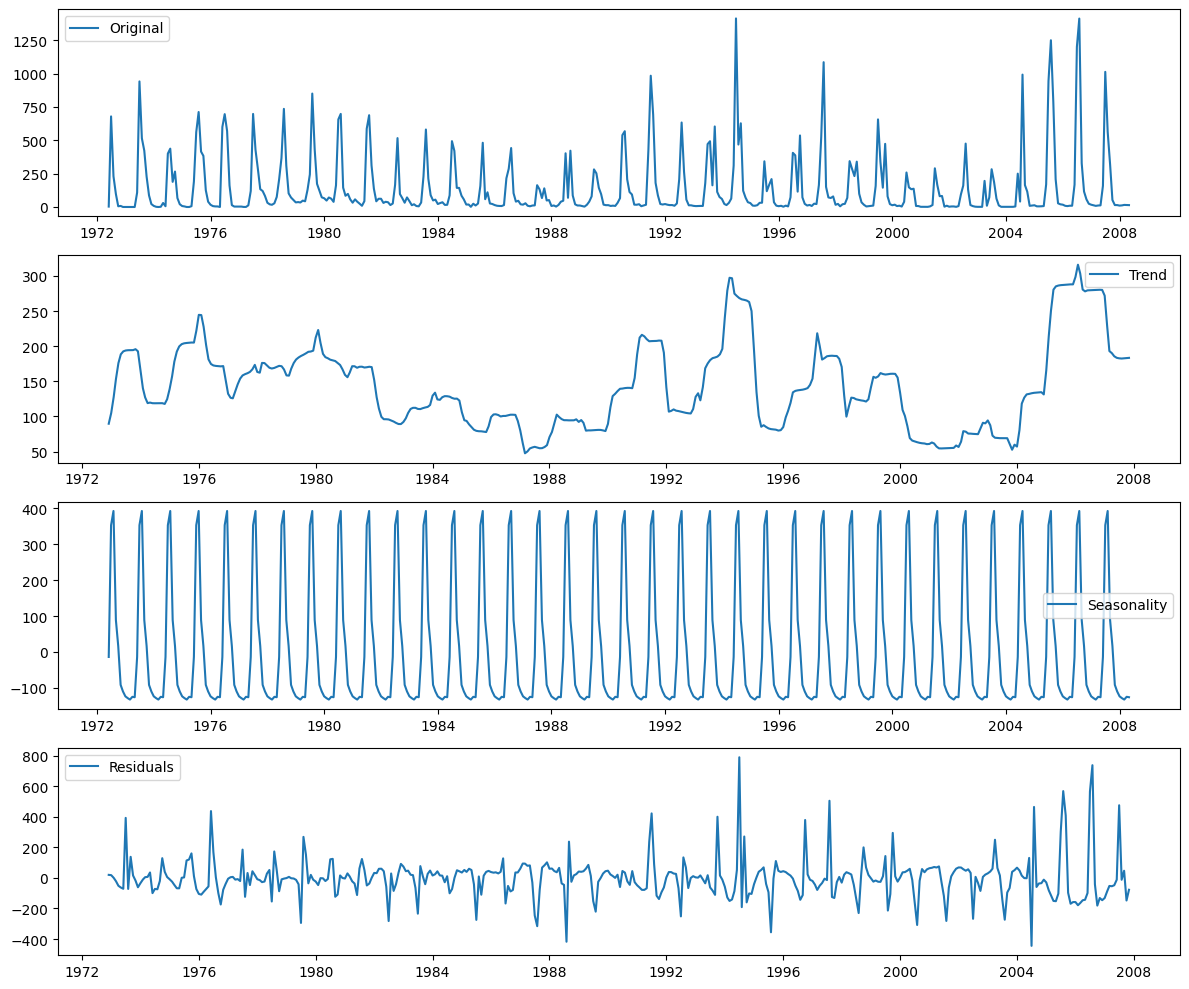

In [37]:
plt.figure(figsize=(12, 10))
plt.subplot(411)
plt.plot(data['Adj_Inflo'], label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal, label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


In [38]:
#Ho: It is non stationary
#H1: It is stationary

def adfuller_test(Adj_Inflo):
    result=adfuller(Adj_Inflo)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")


In [118]:
adfuller_test(data['Adj_Inflo'])

ADF Test Statistic : -3.52492656041859
p-value : 0.007369534305719919
#Lags Used : 13
Number of Observations Used : 418
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


### Plot ACF and PACF:

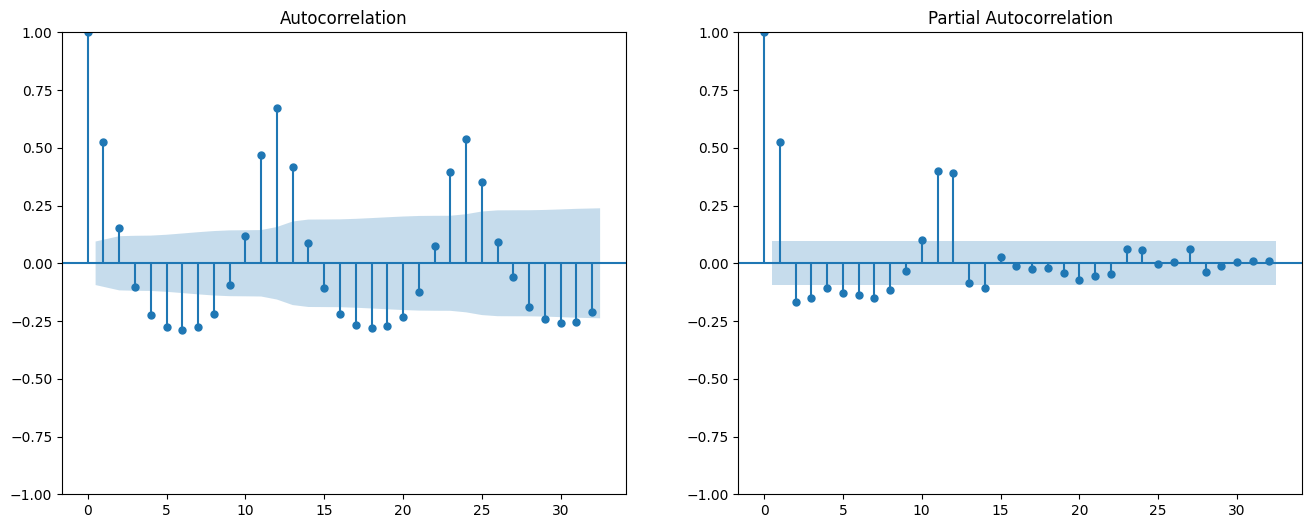

In [41]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
plot_acf(data['Adj_Inflo'].dropna(), lags=32, ax=ax[0])
plot_pacf(data['Adj_Inflo'].dropna(), lags=32, ax=ax[1])
plt.show()


### Fit ARIMA Model:

In [42]:
# Fit the ARIMA model (order to be determined based on basic analysis)
arima_model = ARIMA(data['Adj_Inflo'], order=(1, 0, 1))  # This is an initial guess
arima_result = arima_model.fit()

In [43]:
# Forecast the next 12 months
forecast = arima_result.get_forecast(steps=12)
forecast_values = forecast.predicted_mean

In [44]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

predictions = arima_result.fittedvalues

# Align the length of the predictions with the actual data
aligned_predictions = predictions.iloc[1:]  # Remove the first value to match the actual data length
actual_data = data['Adj_Inflo'].iloc[1:]  # Align with the predictions

# Calculate R-squared and RMSE for the ARIMA model
r_squared = r2_score(actual_data, aligned_predictions)
rmse = np.sqrt(mean_squared_error(actual_data, aligned_predictions))

r_squared, rmse


(0.28735327967832003, np.float64(195.68456820873445))

In [45]:
forecast_values

2008-06-01     80.070443
2008-07-01    118.940426
2008-08-01    133.582210
2008-09-01    139.097568
2008-10-01    141.175126
2008-11-01    141.957714
2008-12-01    142.252504
2009-01-01    142.363547
2009-02-01    142.405376
2009-03-01    142.421132
2009-04-01    142.427067
2009-05-01    142.429303
Freq: MS, Name: predicted_mean, dtype: float64

In [46]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

predictions = arima_result.fittedvalues

# Align predictions with actual data by dropping the first NaN value created by differencing
aligned_predictions = predictions.dropna()

# Recalculate R-squared and RMSE with the aligned data
r_squared = r2_score(data['Adj_Inflo'].iloc[len(data) - len(aligned_predictions):], aligned_predictions)
rmse = np.sqrt(mean_squared_error(data['Adj_Inflo'].iloc[len(data) - len(aligned_predictions):], aligned_predictions))

print(f"R-squared: {r_squared}")
print(f"RMSE: {rmse}")

R-squared: 0.2871137511848426
RMSE: 195.5729864797801


In [47]:
aligned_predictions

Mn-Yr
1972-06-01    142.430654
1972-07-01     68.901030
1972-08-01    471.788741
1972-09-01    124.493535
1972-10-01    119.624350
                 ...    
2008-01-01     79.924511
2008-02-01     78.003182
2008-03-01     79.356856
2008-04-01     81.182354
2008-05-01     80.107800
Length: 432, dtype: float64

In [48]:
# Align predictions with actual data
aligned_predictions = predictions.shift(-1).dropna()

# Recalculate R-squared and RMSE
r_squared = r2_score(data['Adj_Inflo'].iloc[1:len(aligned_predictions)+1], aligned_predictions)
rmse = np.sqrt(mean_squared_error(data['Adj_Inflo'].iloc[1:len(aligned_predictions)+1], aligned_predictions))

r_squared, rmse


(0.28735327967832003, np.float64(195.68456820873445))

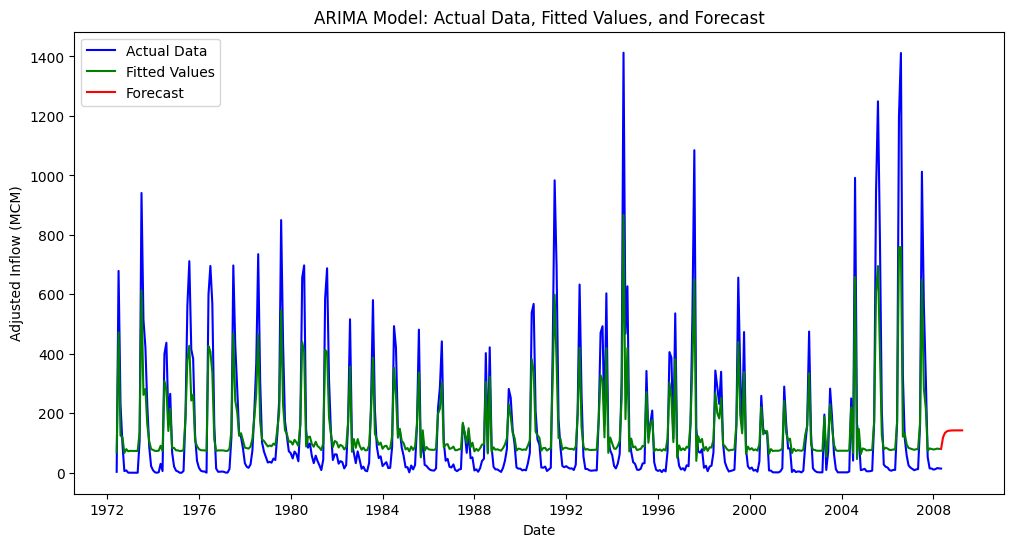

In [49]:
# Plot the actual data, fitted values (predictions), and forecast

# Forecast the next 12 months
forecast_values = forecast.predicted_mean
forecast_index = pd.date_range(start=data.index[-1], periods=12, freq='MS')

plt.figure(figsize=(12, 6))

# Plot actual data
plt.plot(data.index, data['Adj_Inflo'], label='Actual Data', color='blue')

# Plot fitted values (predictions)
plt.plot(data.index[:-1], aligned_predictions, label='Fitted Values', color='green')

# Plot forecasted values
plt.plot(forecast_index, forecast_values, label='Forecast', color='red')

# Add labels and title
plt.title('ARIMA Model: Actual Data, Fitted Values, and Forecast')
plt.xlabel('Date')
plt.ylabel('Adjusted Inflow (MCM)')
plt.legend()

plt.show()


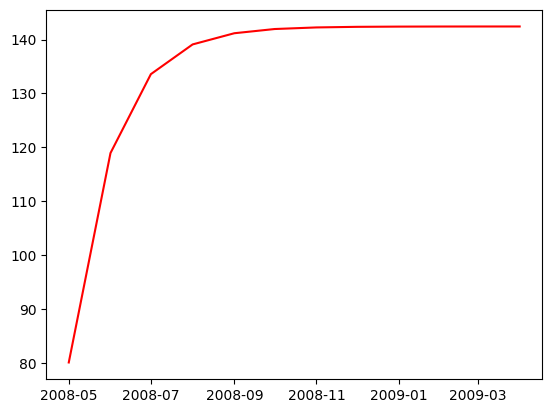

In [50]:
plt.plot(forecast_index, forecast_values, label='Forecast', color='red')


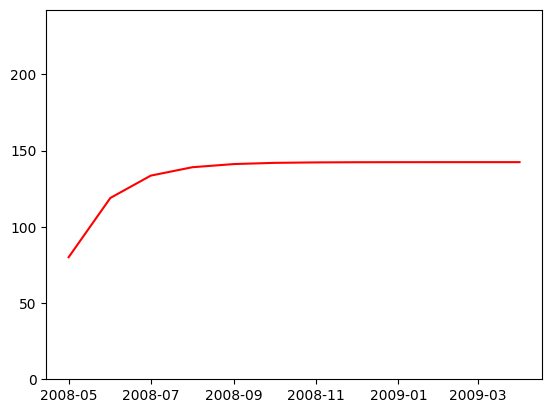

In [51]:
# Your data (assuming forecast_index and forecast_values are already defined)
plt.plot(forecast_index, forecast_values, label='Forecast', color='red')

# Set y-axis limits to start from 100
plt.ylim(0, max(forecast_values) + 100)

plt.show()

In [52]:
r_squared = r2_score(data['Adj_Inflo'].iloc[1:len(forecast_values)+1], forecast_values)

In [53]:
r_squared 

-0.23653704162689326

In [55]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(data['Adj_Inflo'], order=(1, 0, 1), seasonal_order=(1, 0, 1, 12))
model_fit = model.fit()

print(model_fit.summary())


                                    SARIMAX Results                                     
Dep. Variable:                        Adj_Inflo   No. Observations:                  432
Model:             ARIMA(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood               -2772.818
Date:                          Sat, 03 May 2025   AIC                           5557.637
Time:                                  20:17:25   BIC                           5582.047
Sample:                              06-01-1972   HQIC                          5567.274
                                   - 05-01-2008                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        142.5661    107.457      1.327      0.185     -68.046     353.178
ar.L1          0.4641      0.093      4.983      0.

### Forecast Future Values:

In [56]:
# forecast = model_fit.forecast(steps=87)
# print(forecast)


In [57]:
#forecast.plot()

### Applying SARIMA Model

In [58]:
data = pd.read_csv("inflow_data.csv")

In [59]:

# Convert 'Mn-Yr' to datetime format and set it as index
data['Mn-Yr'] = pd.to_datetime(data['Mn-Yr'], format='%b-%y')
data.set_index('Mn-Yr', inplace=True)


In [60]:
# Select the 'Adj_Inflo' column for SARIMA modeling
series = data['Adj_Inflo']

In [61]:
# Split the data into training and test sets
train_size = int(len(series) * 0.9)
train, test = series[:train_size], series[train_size:]


In [62]:
# Fit the SARIMA model
model = SARIMAX(train, order=(1, 0, 1), seasonal_order=(1, 0, 1, 12))
model_fit = model.fit(disp=False)


In [63]:
# Make predictions
predictions = model_fit.forecast(steps=len(test))


In [64]:
predictions

2004-10-01    202.366053
2004-11-01     69.976691
2004-12-01     42.887826
2005-01-01     25.599891
2005-02-01     18.910360
2005-03-01     12.854107
2005-04-01     28.558380
2005-05-01     17.606095
2005-06-01    117.517403
2005-07-01    388.536481
2005-08-01    445.536917
2005-09-01    175.902830
2005-10-01    167.128412
2005-11-01     46.686526
2005-12-01     27.416597
2006-01-01     15.323632
2006-02-01     12.077074
2006-03-01      8.312197
2006-04-01     25.500015
2006-05-01     15.576268
2006-06-01    115.957711
2006-07-01    386.881824
2006-08-01    444.064281
2006-09-01    175.163451
2006-10-01    166.537026
2006-11-01     46.421692
2006-12-01     27.247780
2007-01-01     15.217206
2007-02-01     12.002576
2007-03-01      8.262116
2007-04-01     25.426959
2007-05-01     15.530445
2007-06-01    115.716988
2007-07-01    386.104974
2007-08-01    443.175771
2007-09-01    174.811799
2007-10-01    166.203518
2007-11-01     46.327987
2007-12-01     27.192680
2008-01-01     15.186344


In [65]:
# Calculate RMSE and R-squared
rmse = np.sqrt(mean_squared_error(test, predictions))
r_squared = r2_score(test, predictions)

print(f'RMSE: {rmse}')
print(f'R-squared: {r_squared}')



RMSE: 278.53900526313447
R-squared: 0.45761209306932527


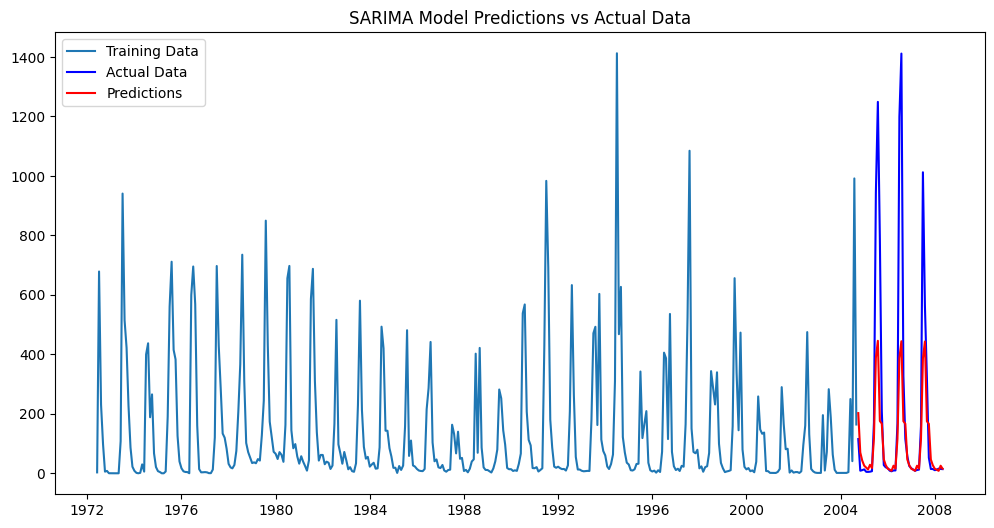

In [66]:
# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Data', color='blue')
plt.plot(test.index, predictions, label='Predictions', color='red')
plt.legend()
plt.title('SARIMA Model Predictions vs Actual Data')
plt.show()

In [67]:
# --- ARIMA Model ---

# Fit the ARIMA model on the entire dataset
arima_model = ARIMA(series, order=(1, 0, 1))      ##(5,1,0)
arima_fit = arima_model.fit()

In [68]:
# Fitted values (in-sample predictions)
arima_fitted_values = arima_fit.fittedvalues

In [69]:
# Forecast the next 12 months with ARIMA
arima_forecast = arima_fit.get_forecast(steps=12)
arima_forecast_values = arima_forecast.predicted_mean
arima_forecast_index = pd.date_range(start=data.index[-1], periods=12, freq='MS')


In [70]:
# --- SARIMA Model ---

# Fit the SARIMA model on the entire dataset
sarima_model = SARIMAX(series, order=(1, 0, 1), seasonal_order=(1, 0, 1, 12))
sarima_fit = sarima_model.fit(disp=False)

In [71]:
# Fitted values (in-sample predictions)
sarima_fitted_values = sarima_fit.fittedvalues

In [72]:
# Forecast the next 12 months with SARIMA
sarima_forecast = sarima_fit.get_forecast(steps=12)
sarima_forecast_values = sarima_forecast.predicted_mean
sarima_forecast_index = pd.date_range(start=data.index[-1], periods=12, freq='MS')


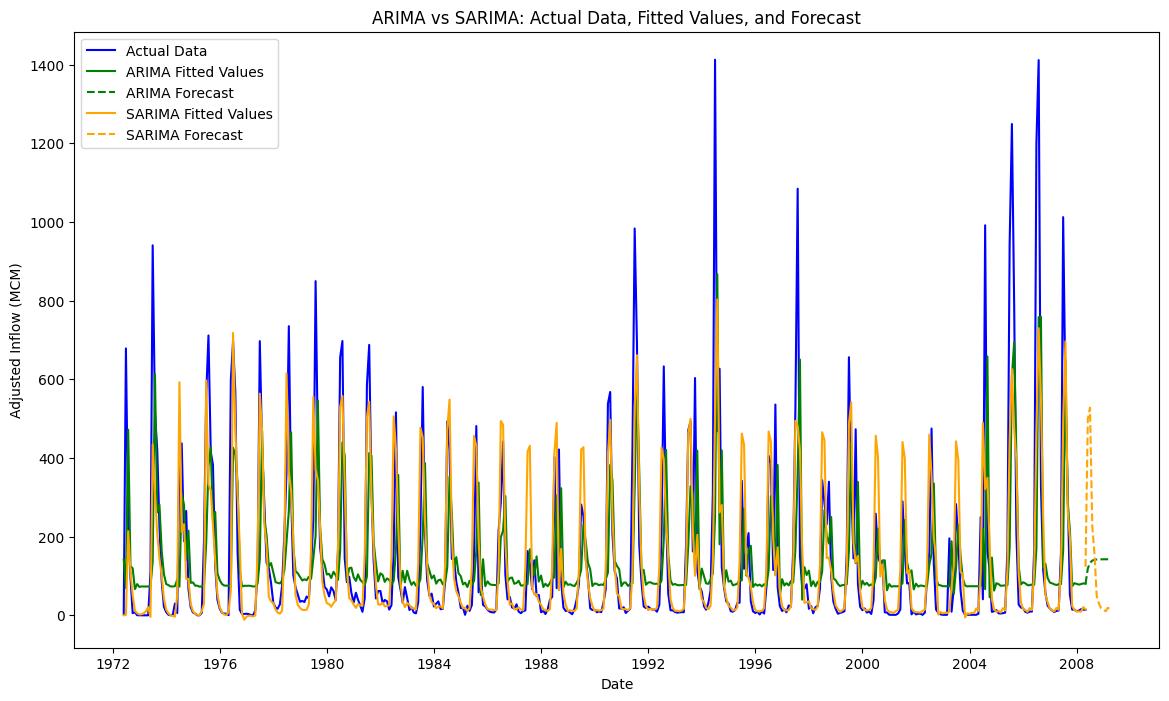

In [73]:
# --- Plotting the Comparison ---

plt.figure(figsize=(14, 8))

# Plot actual data
plt.plot(data.index, data['Adj_Inflo'], label='Actual Data', color='blue')

# Plot ARIMA fitted values
plt.plot(data.index, arima_fitted_values, label='ARIMA Fitted Values', color='green')

# Plot ARIMA forecasted values
plt.plot(arima_forecast_index, arima_forecast_values, label='ARIMA Forecast', color='green', linestyle='dashed')

# Plot SARIMA fitted values
plt.plot(data.index, sarima_fitted_values, label='SARIMA Fitted Values', color='orange')

# Plot SARIMA forecasted values
plt.plot(sarima_forecast_index, sarima_forecast_values, label='SARIMA Forecast', color='orange', linestyle='dashed')

# Add labels and title
plt.title('ARIMA vs SARIMA: Actual Data, Fitted Values, and Forecast')
plt.xlabel('Date')
plt.ylabel('Adjusted Inflow (MCM)')
plt.legend()

plt.show()


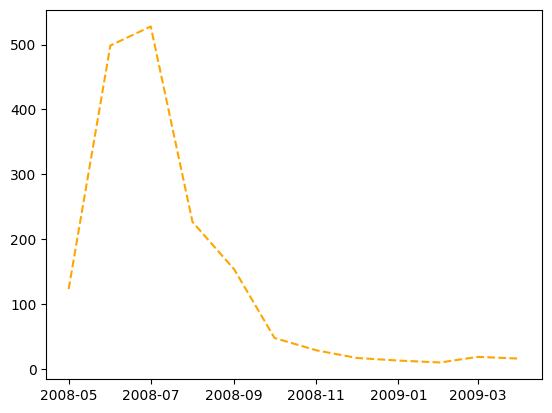

In [74]:
# Plot SARIMA forecasted values
plt.plot(sarima_forecast_index, sarima_forecast_values, label='SARIMA Forecast', color='orange', linestyle='dashed')


In [75]:
import pandas as pd

# Ensure all Date columns are converted to datetime format
data_index = pd.to_datetime(data.index[1:])
forecast_index = pd.to_datetime(forecast_index)
arima_index = pd.to_datetime(data.index)
arima_forecast_index = pd.to_datetime(arima_forecast_values.index)
sarima_index = pd.to_datetime(data.index)
sarima_forecast_index = pd.to_datetime(sarima_forecast_values.index)

# Create DataFrames for fitted values and forecast values
predictions_df = pd.DataFrame({
    'Date': data_index,  # Align with the actual data (excluding the first value)
    'ARIMA_Fitted_Values': aligned_predictions
})

forecast_df = pd.DataFrame({
    'Date': forecast_index,  # Forecast dates
    'ARIMA_Forecast_Values': forecast_values
})

arima_predictions_df = pd.DataFrame({
    'Date': arima_index,  # ARIMA fitted values aligned with the actual data
    'ARIMA_Fitted_Values2': arima_fitted_values
})

arima_forecast_df = pd.DataFrame({
    'Date': arima_forecast_index,  # ARIMA forecast dates
    'ARIMA_Forecast_Values2': arima_forecast_values
})

sarima_predictions_df = pd.DataFrame({
    'Date': sarima_index,  # SARIMA fitted values aligned with the actual data
    'SARIMA_Fitted_Values': sarima_fitted_values
})

sarima_forecast_df = pd.DataFrame({
    'Date': sarima_forecast_index,  # SARIMA forecast dates
    'SARIMA_Forecast_Values': sarima_forecast_values
})

# Concatenate the DataFrames
result_df = pd.concat([predictions_df, forecast_df, arima_predictions_df, arima_forecast_df, sarima_predictions_df, sarima_forecast_df])

# Save the result to a CSV file in a valid directory
output_file_path = 'C:/Users/LOQ/OneDrive/Desktop/Internship_Data/Main_timeSeries_data/predictions_and_forecast.csv'
result_df.to_csv(output_file_path, index=False)

print(f"File saved to {output_file_path}")


File saved to C:/Users/LOQ/OneDrive/Desktop/Internship_Data/Main_timeSeries_data/predictions_and_forecast.csv


In [76]:
sarima_forecast_values

2008-06-01    123.509489
2008-07-01    498.536505
2008-08-01    527.835609
2008-09-01    226.951509
2008-10-01    153.791416
2008-11-01     48.149230
2008-12-01     29.204709
2009-01-01     17.422901
2009-02-01     13.439757
2009-03-01     10.460773
2009-04-01     19.074802
2009-05-01     16.425744
Freq: MS, Name: predicted_mean, dtype: float64

In [77]:
arima_forecast_values

2008-06-01     80.070443
2008-07-01    118.940426
2008-08-01    133.582210
2008-09-01    139.097568
2008-10-01    141.175126
2008-11-01    141.957714
2008-12-01    142.252504
2009-01-01    142.363547
2009-02-01    142.405376
2009-03-01    142.421132
2009-04-01    142.427067
2009-05-01    142.429303
Freq: MS, Name: predicted_mean, dtype: float64

In [78]:
# Extract the last part of the actual data that matches the length of forecast
actual_for_arima = data['Adj_Inflo'][-len(arima_forecast_values):]
actual_for_sarima = data['Adj_Inflo'][-len(sarima_forecast_values):]

# Calculate R-squared for ARIMA forecasted values
r2_arima = r2_score(actual_for_arima, arima_forecast_values)

# Calculate R-squared for SARIMA forecasted values
r2_sarima = r2_score(actual_for_sarima, sarima_forecast_values)

print(f'R-squared for ARIMA forecasted values: {r2_arima:.4f}')
print(f'R-squared for SARIMA forecasted values: {r2_sarima:.4f}')

R-squared for ARIMA forecasted values: -0.0708
R-squared for SARIMA forecasted values: 0.7319


###  Using LSTM (Long Short-Term Memory) model

In [79]:
# Plot the residuals to check for white noise
residuals = arima_result.resid

In [80]:
residuals

Mn-Yr
1972-06-01   -139.400654
1972-07-01    609.733970
1972-08-01   -241.433741
1972-09-01    -27.282535
1972-10-01   -114.131350
                 ...    
2008-01-01    -69.494511
2008-02-01    -65.963182
2008-03-01    -63.726856
2008-04-01    -66.722354
2008-05-01    -66.097800
Length: 432, dtype: float64

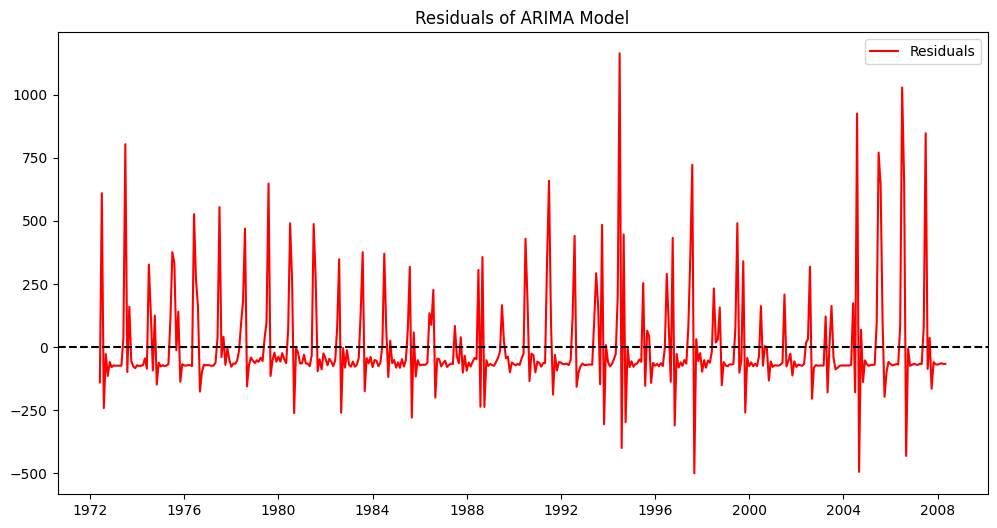

In [81]:
plt.figure(figsize=(12, 6))
plt.plot(residuals, label='Residuals', color='red')
plt.title('Residuals of ARIMA Model')
plt.axhline(y=0, color='black', linestyle='--')
plt.legend()
plt.show()

In [82]:
from statsmodels.stats.diagnostic import acorr_ljungbox

In [83]:
# Perform Ljung-Box test to check if residuals are white noise
ljung_box_result = acorr_ljungbox(residuals, lags=[10], return_df=True)

In [84]:
#arima_result_summary, ljung_box_result

In [85]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, LSTM
from sklearn.metrics import mean_squared_error

In [86]:
# Preprocessing for LSTM
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data['Adj_Inflo'].values.reshape(-1, 1))

In [87]:
# Prepare data for LSTM (sequence length of 50)
def create_dataset(dataset, time_step=50):
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i +time_step), 0])
        Y.append(dataset[i +time_step, 0])
    return np.array(X), np.array(Y)

In [88]:
time_step = 50    #change here look_back
X, Y = create_dataset(scaled_data, time_step)

In [89]:
# Reshape input to be [samples, time steps, features] for LSTM
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [90]:
# Define the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

In [91]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')


In [92]:
# Train the model
model.fit(X, Y, batch_size=32, epochs=500, verbose=1)


Epoch 1/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0329
Epoch 2/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0293
Epoch 3/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0291
Epoch 4/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0268
Epoch 5/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0320
Epoch 6/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0262
Epoch 7/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0175
Epoch 8/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0156
Epoch 9/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0175
Epoch 10/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0182
Epoch 11/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0138
Epoch 12/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0193
Epoch 13/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0150
Epoch 14/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0157
Epoch 15/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - lo

In [93]:
 #Predicting with LSTM
predicted_data = model.predict(X)
predicted_data = scaler.inverse_transform(predicted_data)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [94]:
#predicted_data

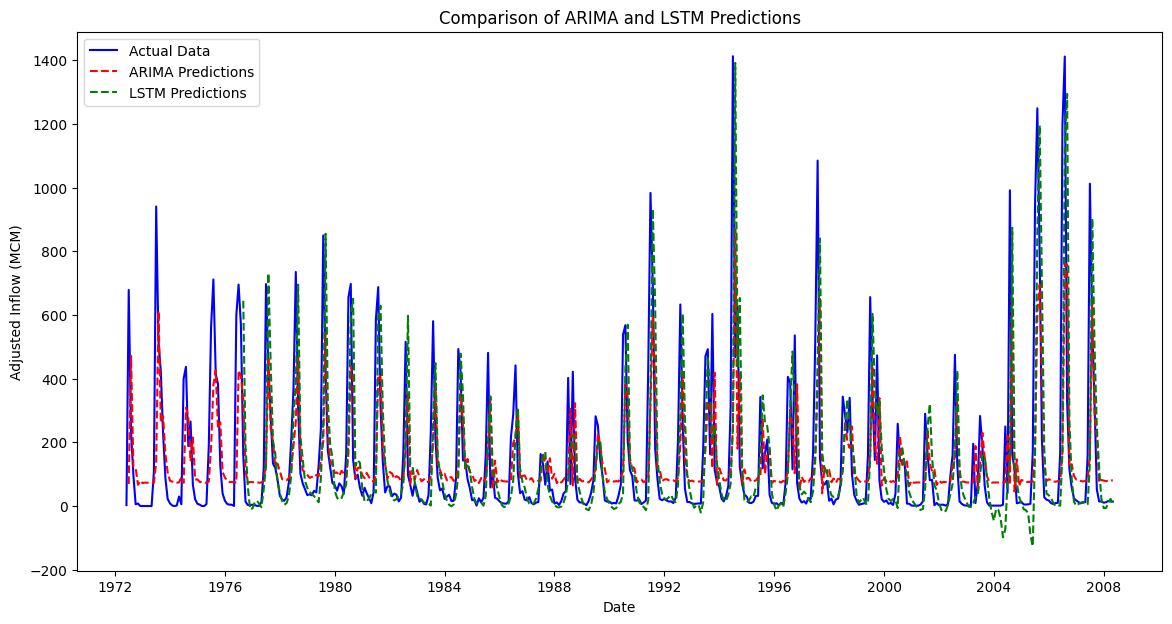

ARIMA RMSE: 195.68456820873445
LSTM RMSE: 209.85607542141506


In [95]:
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Calculate RMSE for ARIMA model
arima_rmse = np.sqrt(mean_squared_error(data['Adj_Inflo'].iloc[1:], aligned_predictions))

# Calculate RMSE for LSTM model
lstm_rmse = np.sqrt(mean_squared_error(data['Adj_Inflo'][-len(predicted_data):], predicted_data))

# Plot actual data, ARIMA predictions, and LSTM predictions
plt.figure(figsize=(14, 7))

# Plot actual data
plt.plot(data.index, data['Adj_Inflo'], color='blue', label='Actual Data')

# Plot ARIMA predictions
plt.plot(data.index[1:], aligned_predictions, color='red', linestyle='--', label='ARIMA Predictions')

# Plot LSTM predictions (aligning with actual data)
plt.plot(data.index[-len(predicted_data):], predicted_data, color='green', linestyle='--', label='LSTM Predictions')

# Add title, labels, and legend
plt.title('Comparison of ARIMA and LSTM Predictions')
plt.xlabel('Date')
plt.ylabel('Adjusted Inflow (MCM)')
plt.legend()

# Show plot
plt.show()

# Print RMSE values
print(f'ARIMA RMSE: {arima_rmse}')
print(f'LSTM RMSE: {lstm_rmse}')


In [96]:
from sklearn.metrics import r2_score

In [97]:
from sklearn.metrics import r2_score

# Calculate R-squared for ARIMA model
arima_r_squared = r2_score(data['Adj_Inflo'].iloc[len(data) - len(aligned_predictions):], aligned_predictions)

# Calculate R-squared for LSTM model
# Ensure that 'predicted_data' is aligned with the actual data
lstm_r_squared = r2_score(data['Adj_Inflo'].iloc[-len(predicted_data):], predicted_data)

# Print R-squared values
print(f'ARIMA R-squared: {arima_r_squared}')
print(f'LSTM R-squared: {lstm_r_squared}')

# Comparison
if arima_r_squared > lstm_r_squared:
    print("ARIMA performs better than LSTM based on R-squared.")
else:
    print("LSTM performs better than ARIMA based on R-squared.")


ARIMA R-squared: 0.28735327967832003
LSTM R-squared: 0.16036856892294693
ARIMA performs better than LSTM based on R-squared.


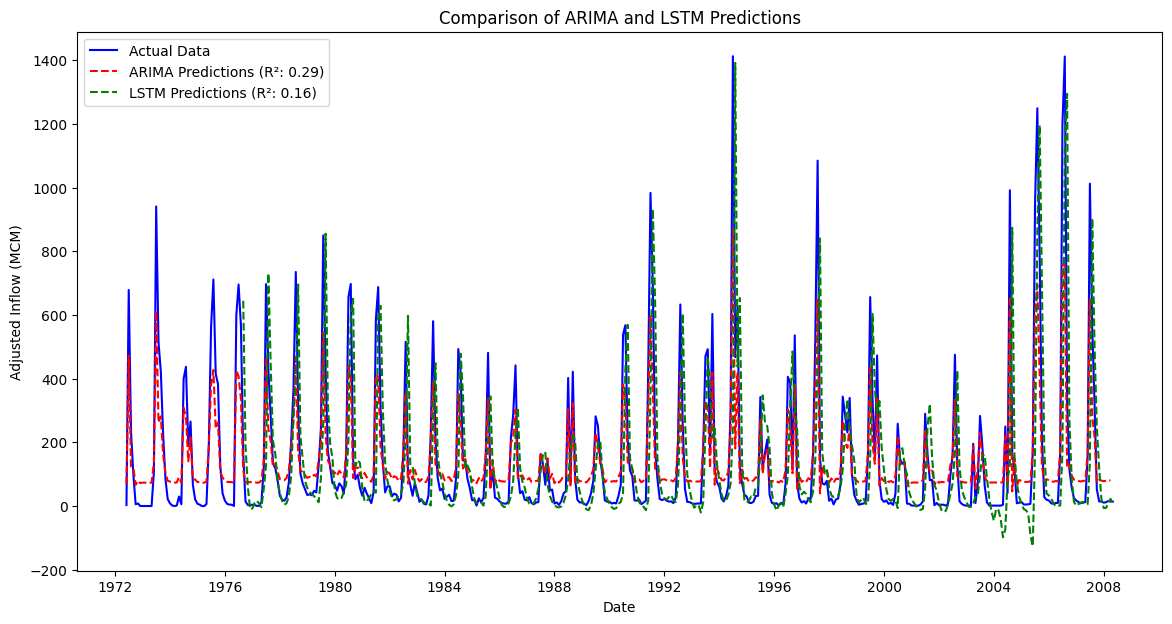

ARIMA R-squared: 0.28735327967832003
LSTM R-squared: 0.16036856892294693


In [98]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Calculate R-squared for ARIMA model
arima_r_squared = r2_score(data['Adj_Inflo'].iloc[len(data) - len(aligned_predictions):], aligned_predictions)

# Calculate R-squared for LSTM model
lstm_r_squared = r2_score(data['Adj_Inflo'].iloc[-len(predicted_data):], predicted_data)

# Plot actual data, ARIMA predictions, and LSTM predictions
plt.figure(figsize=(14, 7))

# Plot actual data
plt.plot(data.index, data['Adj_Inflo'], color='blue', label='Actual Data')

# Plot ARIMA predictions
plt.plot(data.index[:-1], aligned_predictions, color='red', linestyle='--', label=f'ARIMA Predictions (R²: {arima_r_squared:.2f})')

# Plot LSTM predictions
plt.plot(data.index[-len(predicted_data):], predicted_data, color='green', linestyle='--', label=f'LSTM Predictions (R²: {lstm_r_squared:.2f})')

# Add title, labels, and legend
plt.title('Comparison of ARIMA and LSTM Predictions')
plt.xlabel('Date')
plt.ylabel('Adjusted Inflow (MCM)')
plt.legend()

# Show plot
plt.show()

# Print R-squared values
print(f'ARIMA R-squared: {arima_r_squared}')
print(f'LSTM R-squared: {lstm_r_squared}')


In [99]:
# Plotting actual vs predicted values
plt.figure(figsize=(12, 6))


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

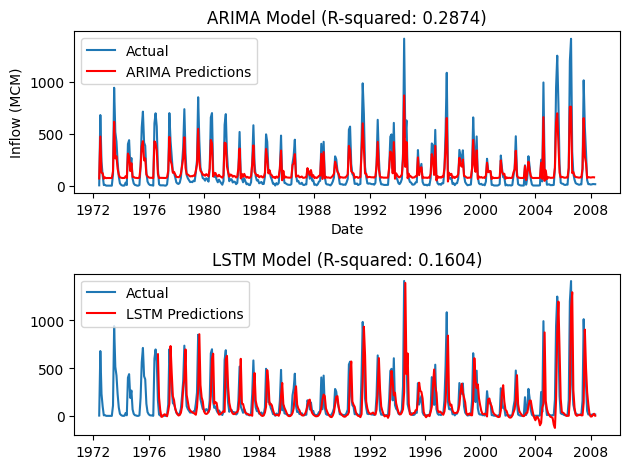

In [100]:
# Plot ARIMA predictions
plt.subplot(2, 1, 1)
plt.plot(data.index,data['Adj_Inflo'], label='Actual')
plt.plot(data.index[:-1], aligned_predictions, label='ARIMA Predictions', color='red')
plt.title(f'ARIMA Model (R-squared: {arima_r_squared:.4f})')
plt.xlabel('Date')  # X-axis label
plt.ylabel('Inflow (MCM)')  # Y-axis label
plt.legend()


# Plot LSTM predictions
plt.subplot(2, 1, 2)
plt.plot(data.index,data['Adj_Inflo'], label='Actual')
plt.plot(data.index[-len(predicted_data):], predicted_data, label='LSTM Predictions', color='red')
plt.title(f'LSTM Model (R-squared: {lstm_r_squared:.4f})')
plt.legend()

plt.tight_layout()
plt.show()



###  Applying Bidirectional

In [101]:
from keras.layers import LSTM, Dense, Bidirectional

###  1. Data Preprocessing

In [102]:


# Normalize the data for LSTM model
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[['Adj_Inflo']])

# Convert the data into sequences for the LSTM model
def create_sequences(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 10  # You can adjust this value
X, y = create_sequences(scaled_data, time_step)

# Reshape X to be [samples, time steps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))


###  2. Build the Bidirectional LSTM Model

In [103]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Bidirectional

# Build the Bidirectional LSTM model
model = Sequential()
model.add(Bidirectional(LSTM(50, return_sequences=True), input_shape=(time_step, 1)))
model.add(Bidirectional(LSTM(50)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')


###  3. Train the Model

In [104]:
# Train the model
model.fit(X, y, epochs=500, batch_size=32, verbose=1)


Epoch 1/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0317
Epoch 2/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0227
Epoch 3/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0302
Epoch 4/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0204
Epoch 5/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0224
Epoch 6/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0226
Epoch 7/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0180 
Epoch 8/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0199
Epoch 9/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0162
Epoch 10/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0145
Epoch 11/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0177
Epoch 12/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0167
Epoch 13/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0170 
Epoch 14/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0156
Epoch 15/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0151
Ep

###  4. Make Predictions

In [105]:
# Make predictions using the trained model
train_predict = model.predict(X)

# Inverse transform the predictions to match the original scale
train_predict = scaler.inverse_transform(train_predict.reshape(-1, 1))

# Align the predictions with the actual data
predicted_data = np.empty_like(scaled_data)
predicted_data[:, :] = np.nan
predicted_data[time_step:len(train_predict) + time_step, :] = train_predict


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


###  5. Calculate R-squared for LSTM Bidirectional and ARIMA

In [106]:
import numpy as np
from sklearn.metrics import r2_score

# Ensure there are no NaN values in predicted_data
predicted_data_nonan = predicted_data[~np.isnan(predicted_data)].flatten()

# Ensure that the actual data aligns with the predicted_data without NaN
actual_data_nonan = data['Adj_Inflo'][time_step:time_step + len(predicted_data_nonan)]

# Calculate R-squared for ARIMA model
arima_r_squared = r2_score(data['Adj_Inflo'].iloc[len(data) - len(aligned_predictions):], aligned_predictions)

# Calculate R-squared for Bidirectional LSTM model
lstm_r_squared = r2_score(actual_data_nonan, predicted_data_nonan)

print(f'ARIMA R-squared: {arima_r_squared}')
print(f'Bidirectional LSTM R-squared: {lstm_r_squared}')


ARIMA R-squared: 0.28735327967832003
Bidirectional LSTM R-squared: 0.7594684255136661


###  6. Comparison of ARIMA and Bidirectional LSTM Prediction

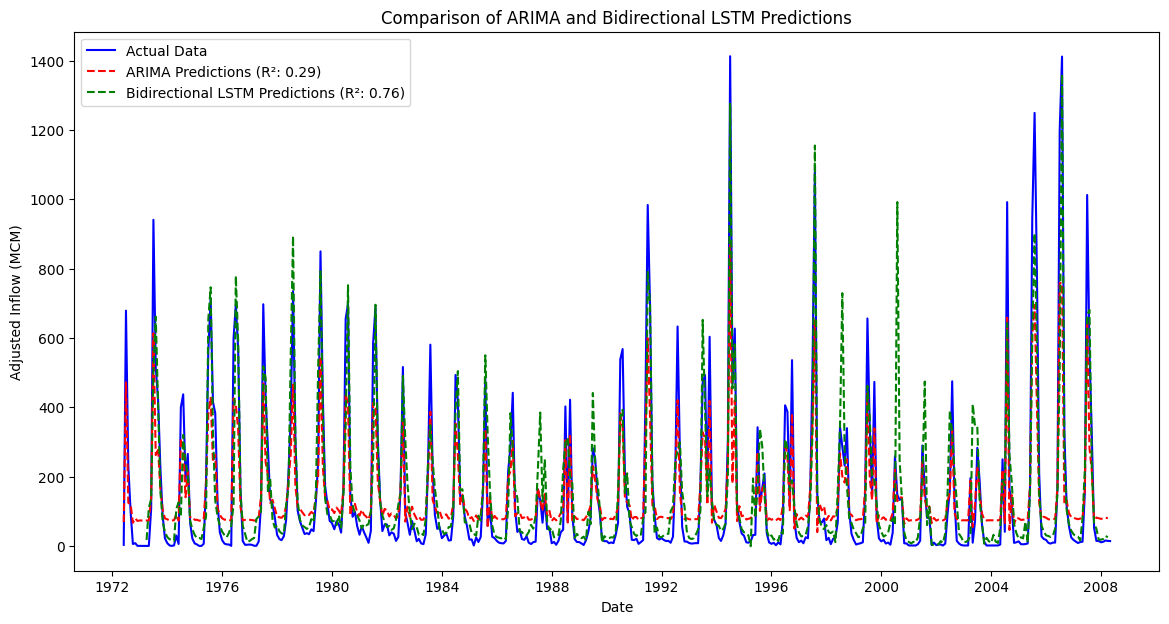

In [107]:
import matplotlib.pyplot as plt

# Plot actual data, ARIMA predictions, and Bidirectional LSTM predictions
plt.figure(figsize=(14, 7))

# Plot actual data
plt.plot(data.index, data['Adj_Inflo'], color='blue', label='Actual Data')

# Plot ARIMA predictions
plt.plot(data.index[:-1], aligned_predictions, color='red', linestyle='--', label=f'ARIMA Predictions (R²: {arima_r_squared:.2f})')

# Plot Bidirectional LSTM predictions
plt.plot(data.index[time_step:], predicted_data[time_step:], color='green', linestyle='--', label=f'Bidirectional LSTM Predictions (R²: {lstm_r_squared:.2f})')

# Add title, labels, and legend
plt.title('Comparison of ARIMA and Bidirectional LSTM Predictions')
plt.xlabel('Date')
plt.ylabel('Adjusted Inflow (MCM)')
plt.legend()

# Show plot
plt.show()


In [108]:
aligned_predictions

Mn-Yr
1972-06-01     68.901030
1972-07-01    471.788741
1972-08-01    124.493535
1972-09-01    119.624350
1972-10-01     66.698602
                 ...    
2007-12-01     79.924511
2008-01-01     78.003182
2008-02-01     79.356856
2008-03-01     81.182354
2008-04-01     80.107800
Length: 431, dtype: float64

In [109]:
# Forecasting future values
def forecast_future(model, last_sequence, future_steps):
    forecast = []
    current_sequence = last_sequence
    
    for _ in range(future_steps):
        prediction = model.predict(current_sequence.reshape(1, time_step, 1))
        forecast.append(prediction[0, 0])
        current_sequence = np.append(current_sequence[1:], prediction, axis=0)
    
    return np.array(forecast)

In [110]:
def forecast_future(model, last_sequence, future_steps, time_step):
    # Ensure last_sequence has the correct shape
    if len(last_sequence) != time_step:
        raise ValueError(f"last_sequence length {len(last_sequence)} does not match time_step {time_step}")

    current_sequence = last_sequence.reshape(1, time_step, 1)  # Reshape to (1, time_step, 1)
    forecast = []

    for _ in range(future_steps):
        prediction = model.predict(current_sequence)
        forecast.append(prediction[0, 0])
        current_sequence = np.append(current_sequence[:, 1:, :], prediction.reshape(1, 1, 1), axis=1)

    return np.array(forecast)

# Assuming scaled_data and time_step are defined
future_steps = 24  # Number of months to forecast
last_sequence = scaled_data[-time_step:]  # Get the last sequence from the dataset
forecasted_values = forecast_future(model, last_sequence, future_steps, time_step)

# Forecast the next 12 months with SARIMA
sarima_forecast = sarima_fit.get_forecast(steps=12)
sarima_forecast_values = sarima_forecast.predicted_mean
sarima_forecast_index = pd.date_range(start=data.index[-1], periods=24, freq='MS')

# Create a DataFrame to hold the forecasted values
forecast_df = pd.DataFrame({
    'SARIMA': sarima_forecast_values,
    'LSTM_Bidirectional': forecasted_values
}, index=sarima_forecast_index)

print(forecast_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
                SARIMA  LSTM_Bidirectional
2008-05-01         NaN            0.073883
20

In [112]:
forecasted_values

array([0.07388295, 0.371339  , 0.2764634 , 0.07588118, 0.13772266,
       0.03910232, 0.03430326, 0.03641393, 0.03809622, 0.0448339 ,
       0.05785539, 0.112652  , 0.29065505, 0.647314  , 0.32194576,
       0.08855458, 0.07256883, 0.06677452, 0.0632026 , 0.06482702,
       0.06977875, 0.07919948, 0.10979778, 0.70576316], dtype=float32)

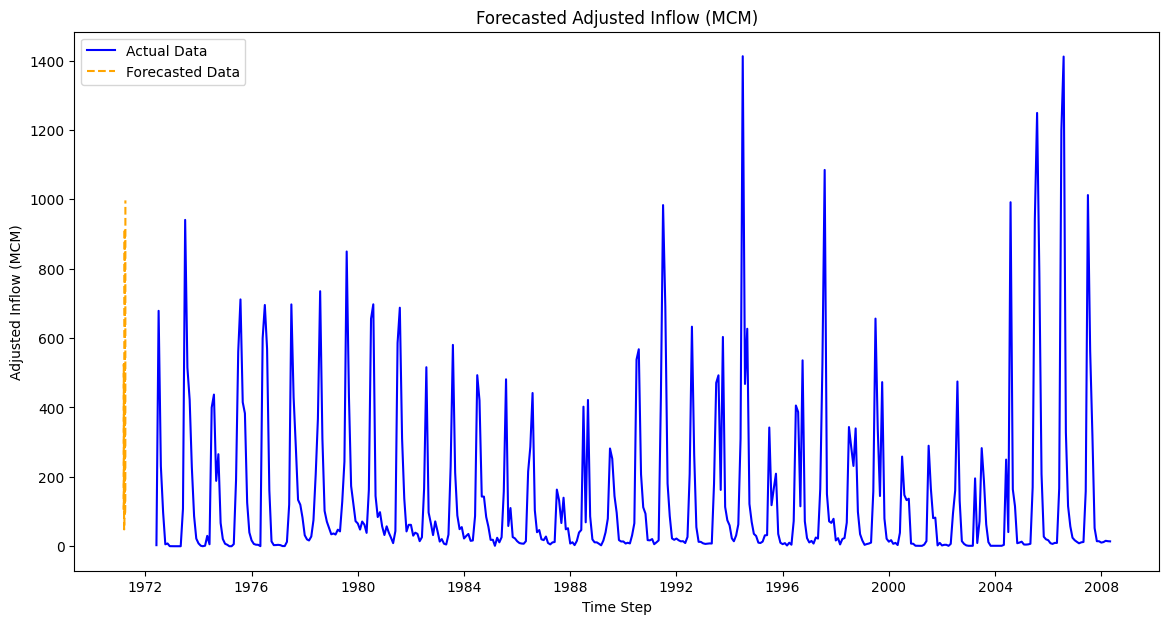

In [113]:
# Inverse transform the forecasted values
forecasted_values = scaler.inverse_transform(forecasted_values.reshape(-1, 1))

# Extend the time index for the forecasted values
forecast_index = np.arange(len(data), len(data) + future_steps)

# Plot the results
plt.figure(figsize=(14, 7))

# Plot actual data
plt.plot(data.index, data['Adj_Inflo'], color='blue', label='Actual Data')

# Plot forecasted data
plt.plot(forecast_index, forecasted_values, color='orange', linestyle='--', label='Forecasted Data')

# Add title, labels, and legend
plt.title('Forecasted Adjusted Inflow (MCM)')
plt.xlabel('Time Step')
plt.ylabel('Adjusted Inflow (MCM)')
plt.legend()

# Show plot
plt.show()

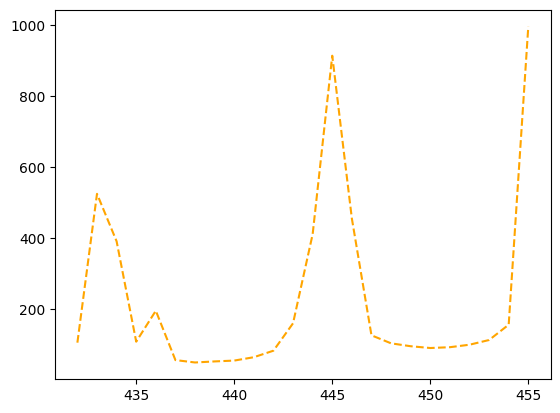

In [116]:
plt.plot(forecast_index, forecasted_values, color='orange', linestyle='--', label='Forecasted Data')